In [5]:
import numpy as np

# Load the stepping dataset
data = np.load('stepping_dataset_12.06_fixed.npz')

# Display available keys
print("Available keys in the dataset:")
print(list(data.keys()))

# Load the data (example - adjust based on actual keys)
# Uncomment and modify based on the actual structure:
for key in data.keys():
    print(f"{key}: shape={data[key].shape}, dtype={data[key].dtype}")


Available keys in the dataset:
['q', 'qd', 'T_blf', 'T_brf', 'T_stsw', 'p_wcom', 'T_wbase', 'v_b', 'cmd_footstep', 'cmd_stance', 'cmd_countdown', 'traj', 'traj_dt']
q: shape=(2619688, 36), dtype=float64
qd: shape=(2619688, 35), dtype=float64
T_blf: shape=(2619688, 4), dtype=float64
T_brf: shape=(2619688, 4), dtype=float64
T_stsw: shape=(2619688, 4), dtype=float64
p_wcom: shape=(2619688, 3), dtype=float64
T_wbase: shape=(2619688, 7), dtype=float64
v_b: shape=(2619688, 6), dtype=float64
cmd_footstep: shape=(2619688, 4), dtype=float64
cmd_stance: shape=(2619688, 1), dtype=float64
cmd_countdown: shape=(2619688, 1), dtype=float64
traj: shape=(11241,), dtype=int32
traj_dt: shape=(), dtype=float64


In [6]:
# Extract all data arrays from the loaded dataset
q = data['q']  # Joint positions: (781774, 36)
qd = data['qd']  # Joint velocities: (781774, 35)
T_blf = data['T_blf']  # Left front foot timing: (781774, 4)
T_brf = data['T_brf']  # Right front foot timing: (781774, 4)
T_stsw = data['T_stsw']  # Stance/swing timing: (781774, 4)
p_wcom = data['p_wcom']  # World COM position: (781774, 3)
T_wbase = data['T_wbase']  # World base transform: (781774, 7)
v_b = data['v_b']  # Base velocity: (781774, 6)
cmd_footstep = data['cmd_footstep']  # Footstep commands: (781774, 4)
cmd_stance = data['cmd_stance']  # Stance commands: (781774, 1)
cmd_countdown = data['cmd_countdown']  # Countdown commands: (781774, 1)
traj = data['traj']  # Trajectory indices: (4048,)
traj_dt = data['traj_dt']  # Trajectory time step: scalar

# Display summary
print(f"Dataset summary:")
print(f"  Total timesteps: {len(q)}")
print(f"  Number of trajectories: {len(traj)}")
print(f"  Trajectory time step: {traj_dt}")
print(f"  Joint positions (q): {q.shape}")
print(f"  Joint velocities (qd): {qd.shape}")


Dataset summary:
  Total timesteps: 2619688
  Number of trajectories: 11241
  Trajectory time step: 0.02
  Joint positions (q): (2619688, 36)
  Joint velocities (qd): (2619688, 35)


Plotting timesteps 12000 to 12399 (total: 400 timesteps)


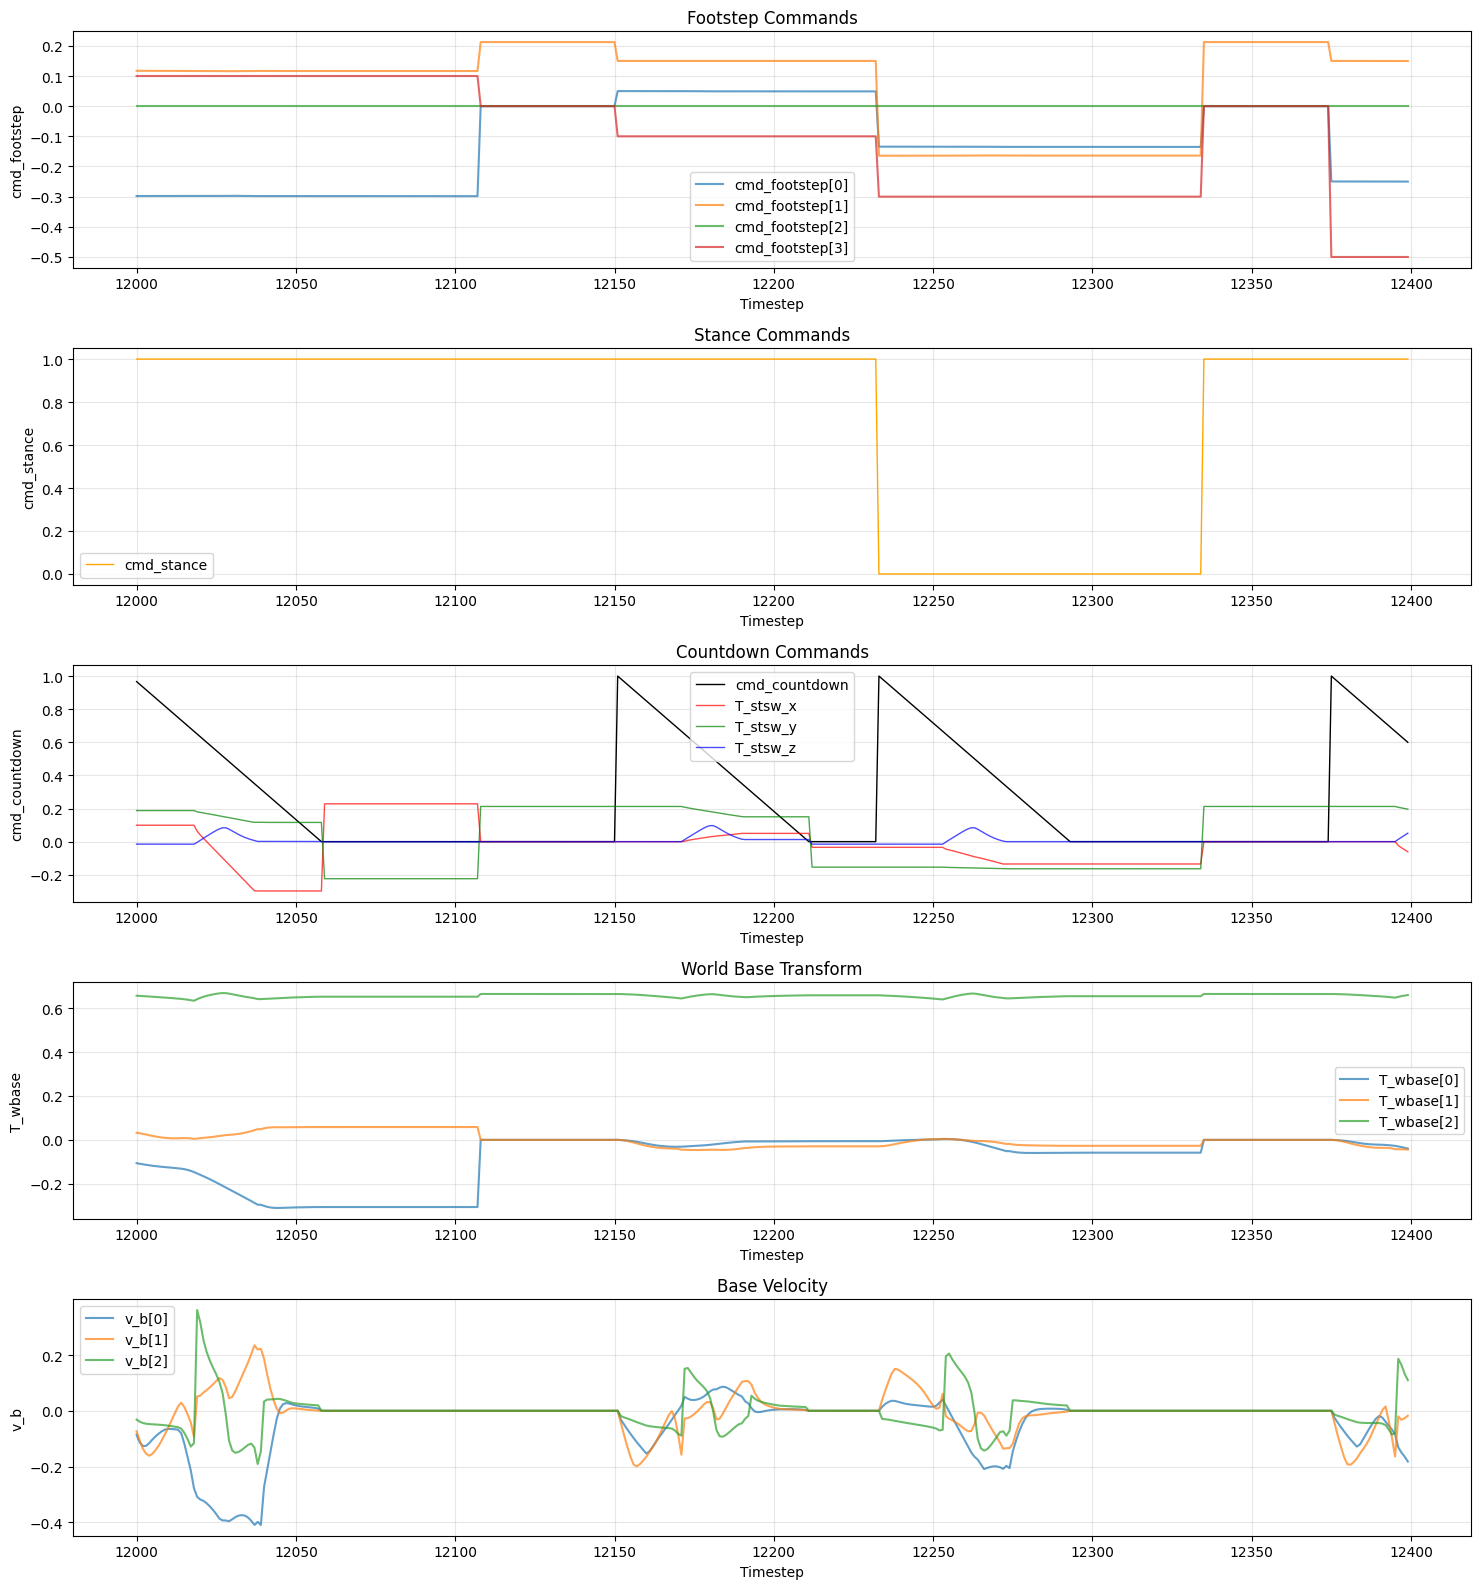


Timesteps 12000 to 12399:

cmd_footstep (timesteps 12000 to 12399):
[[-0.29790009  0.11730681  0.          0.1       ]
 [-0.29789967  0.11730416  0.          0.1       ]
 [-0.29790007  0.11729072  0.          0.1       ]
 ...
 [-0.24994921  0.14978684  0.         -0.5       ]
 [-0.25001407  0.14976621  0.         -0.5       ]
 [-0.25006476  0.14972763  0.         -0.5       ]]

cmd_stance (timesteps 12000 to 12399):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

In [14]:
import matplotlib.pyplot as plt

# Create timestep array
timesteps = np.arange(len(cmd_footstep))

# Option to plot subset (set to None to plot all, or specify start/end timesteps)
# Set start_timestep and end_timestep to select a range, or set both to None to plot all
start_timestep = 12000  # Start timestep (inclusive)
end_timestep = 12400  # End timestep (exclusive), or None to plot until the end

if start_timestep is not None or end_timestep is not None:
    start_idx = start_timestep if start_timestep is not None else 0
    end_idx = end_timestep if end_timestep is not None else len(timesteps)
    # Ensure indices are within bounds
    start_idx = max(0, min(start_idx, len(timesteps)))
    end_idx = max(start_idx, min(end_idx, len(timesteps)))
    
    timesteps = timesteps[start_idx:end_idx]
    cmd_footstep_plot = cmd_footstep[start_idx:end_idx]
    cmd_stance_plot = cmd_stance[start_idx:end_idx].squeeze()
    cmd_countdown_plot = cmd_countdown[start_idx:end_idx].squeeze()
    T_stsw_plot = T_stsw[start_idx:end_idx]
    T_wbase_plot = T_wbase[start_idx:end_idx]
    v_b_plot = v_b[start_idx:end_idx]
    
    print(f"Plotting timesteps {start_idx} to {end_idx-1} (total: {end_idx - start_idx} timesteps)")
else:
    cmd_footstep_plot = cmd_footstep
    cmd_stance_plot = cmd_stance.squeeze()
    cmd_countdown_plot = cmd_countdown.squeeze()
    T_stsw_plot = T_stsw
    T_wbase_plot = T_wbase
    v_b_plot = v_b
    print(f"Plotting all timesteps (total: {len(timesteps)} timesteps)")

# Create figure with subplots
fig, axes = plt.subplots(5, 1, figsize=(15, 16))

# Plot cmd_footstep (4 components)
ax = axes[0]
for i in range(cmd_footstep_plot.shape[1]):
    ax.plot(timesteps, cmd_footstep_plot[:, i], label=f'cmd_footstep[{i}]', alpha=0.7)
ax.set_xlabel('Timestep')
ax.set_ylabel('cmd_footstep')
ax.set_title('Footstep Commands')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot cmd_stance
ax = axes[1]
ax.plot(timesteps, cmd_stance_plot, label='cmd_stance', color='orange', linewidth=1)
ax.set_xlabel('Timestep')
ax.set_ylabel('cmd_stance')
ax.set_title('Stance Commands')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot cmd_countdown
ax = axes[2]
ax.plot(timesteps, cmd_countdown_plot, label='cmd_countdown', color='black', linewidth=1)
ax.plot(timesteps, T_stsw_plot[:, 0], label='T_stsw_x', color='red', linewidth=1, alpha=0.7)
ax.plot(timesteps, T_stsw_plot[:, 1], label='T_stsw_y', color='green', linewidth=1, alpha=0.7)
ax.plot(timesteps, T_stsw_plot[:, 2], label='T_stsw_z', color='blue', linewidth=1, alpha=0.7)
ax.set_xlabel('Timestep')
ax.set_ylabel('cmd_countdown')
ax.set_title('Countdown Commands')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot T_wbase (7 components)
ax = axes[3]
for i in range(3):
    ax.plot(timesteps, T_wbase_plot[:, i], label=f'T_wbase[{i}]', alpha=0.7)
ax.set_xlabel('Timestep')
ax.set_ylabel('T_wbase')
ax.set_title('World Base Transform')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot v_b (6 components)
ax = axes[4]
for i in range(3):
    ax.plot(timesteps, v_b_plot[:, i], label=f'v_b[{i}]', alpha=0.7)
ax.set_xlabel('Timestep')
ax.set_ylabel('v_b')
ax.set_title('Base Velocity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the selected range of timesteps
if start_timestep is not None or end_timestep is not None:
    start_idx = start_timestep if start_timestep is not None else 0
    end_idx = end_timestep if end_timestep is not None else len(cmd_footstep)
    start_idx = max(0, min(start_idx, len(cmd_footstep)))
    end_idx = max(start_idx, min(end_idx, len(cmd_footstep)))
    print(f"\nTimesteps {start_idx} to {end_idx-1}:")
    print(f"\ncmd_footstep (timesteps {start_idx} to {end_idx-1}):")
    print(cmd_footstep[start_idx:end_idx])
    print(f"\ncmd_stance (timesteps {start_idx} to {end_idx-1}):")
    print(cmd_stance[start_idx:end_idx].squeeze())
    print(f"\ncmd_countdown (timesteps {start_idx} to {end_idx-1}):")
    print(cmd_countdown[start_idx:end_idx].squeeze())
else:
    print(f"\nAll timesteps:")
    print(f"\ncmd_footstep (first 200 timesteps):")
    print(cmd_footstep[:200])
    print(f"\ncmd_stance (first 200 timesteps):")
    print(cmd_stance[:200].squeeze())
    print(f"\ncmd_countdown (first 200 timesteps):")
    print(cmd_countdown[:200].squeeze())

# Print some statistics
print(f"\nStatistics:")
print(f"cmd_footstep - shape: {cmd_footstep.shape}, min: {cmd_footstep.min():.4f}, max: {cmd_footstep.max():.4f}")
print(f"cmd_stance - shape: {cmd_stance.shape}, min: {cmd_stance.min():.4f}, max: {cmd_stance.max():.4f}")
print(f"cmd_countdown - shape: {cmd_countdown.shape}, min: {cmd_countdown.min():.4f}, max: {cmd_countdown.max():.4f}")
